In [1]:
import os
import random
import sys
import matplotlib.pyplot as plt
import albumentations as A
import datetime
import numpy as np
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from torchinfo import summary
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Dataset

from model.UNet import UNet
from model.ResUNet import ResUNet
from model.RLUNet import RLUNet
from src.crack_segmentation.helper_func import *

c:\Users\ilham\Documents\Sipil\S2\THESIS\Coding\lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## CrackSeg9k

In [7]:
class CrackSeg9kDataset(Dataset):
    def __init__(self, image_path, mask_path, limit=None, augment=False):
        # self.root_path = root_path
        self.limit = limit
        self.augment = augment
        self.images = sorted([image_path + fname for fname in os.listdir(image_path)])[:self.limit]
        self.masks = sorted([mask_path + fname for fname in os.listdir(mask_path)])[:self.limit]

        self.transform = transforms.Compose([
            # TODO: understand the need for size transformation
            # transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])

        if self.limit is None:
            # get all images without size limit
            self.limit = len(self.images)

    def __getitem__(self, index):
        img = Image.open(self.images[index]).convert("RGB")
        mask = Image.open(self.masks[index]).convert("L")
        mask = mask.point(lambda x: 255 if x > 128 else 0, '1')

        return self.transform(img), self.transform(mask)

    def __len__(self):
        return min(len(self.images), self.limit)

## OmniCrack30k

In [4]:
database_name = "OmniCrack30k"

class OmniCrack30kDataset(Dataset):
    def __init__(self, image_path, mask_path, limit=None, augment=False):
        # self.root_path = root_path
        self.limit = limit
        self.augment = augment
        self.images = sorted([image_path + fname for fname in os.listdir(image_path)])[:self.limit]
        self.masks = sorted([mask_path + fname for fname in os.listdir(mask_path)])[:self.limit]

        self.transform = transforms.Compose([
            # TODO: understand the need for size transformation
            # transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])

        if self.limit is None:
            # get all images without size limit
            self.limit = len(self.images)

    def __getitem__(self, index):
        img = Image.open(self.images[index]).convert("RGB")
        mask = Image.open(self.masks[index]).convert("L")
        mask = mask.point(lambda x: 255 if x < 128 else 0, '1')

        return self.transform(img), self.transform(mask)

    def __len__(self):
        return min(len(self.images), self.limit)

## MODEL SHOWDOWN CRACKSEG9K

In [5]:
torch.cuda.empty_cache()

In [6]:
# Testing Dataset
testing_dir = "./CrackDatabase/crackseg9k/Test/Image/"
target_dir = "./CrackDatabase/crackseg9k/Test/Mask/"
# model_dir_1 = "./model_state/UNET_OmniCrack30k_072515_155812.pth"
model_dir_1 = "./model_state/FINAL_UNET_crackseg9k_200_4_400.pth"
model_dir_2 = "./model_state/RLUNET_crackseg9k_072528_002146.pth"
model_dir_3 = "./model_state/RLUNET_CC_072528_150829.pth"
model_dir_4 = "./model_state/FINAL_RLUNET_CRACK500_100_5.pth"
# model_dir_4 = "./model_state/FINAL_RLUNET_OmniCrack30k_100_16.pth"
# model_dir_4 = "./model_state/RLUnet/OmniCrack30k_100_16.pth"

model_1 = UNet(n_channels=3, n_classes=1).to('cuda')
# model_2 = RLUNet().to('cuda')
# model_3 = RLUNet().to('cuda')
model_4 = RLUNet().to('cuda')

model_1.load_state_dict(torch.load(model_dir_1)['state_dict'], strict=False)
# model_2.load_state_dict(torch.load(model_dir_2), strict=False)
# model_3.load_state_dict(torch.load(model_dir_3), strict=False)
model_4.load_state_dict(torch.load(model_dir_4)['state_dict'], strict=False)

image_test = CrackSeg9kDataset(testing_dir, target_dir, limit=200)
image_test = DataLoader(dataset=image_test,
                        batch_size=1
                        )

image_l = [im for im in image_test]
print(image_l[2][0].shape, end="\n")

limit_min = 70
limit_max = 80
limit = 7
idx = 1
plt.figure(figsize=(32, 8))
fig = plt.figure(constrained_layout=True)
subfigs = fig.subfigures(nrows=4, ncols=1)
fig.suptitle('crackseg9k')

subfigs[0].supylabel('Image', fontsize=8)
axs = subfigs[0].subplots(nrows=1, ncols=limit)
for img, ax in zip(image_l[limit_min:limit_max], axs):
    idx = idx + 1
    ax.imshow(img[0].squeeze(0).permute(1, 2, 0))
    ax.axis('off')

subfigs[1].supylabel('Truth', fontsize=8)
axs = subfigs[1].subplots(nrows=1, ncols=limit)
for img, ax in zip(image_l[limit_min:limit_max], axs):
    idx = idx + 1
    ax.imshow(img[1].squeeze(0).permute(1, 2, 0), cmap='gray')
    ax.axis('off')

subfigs[2].supylabel('U-Net', fontsize=8)
axs = subfigs[2].subplots(nrows=1, ncols=limit)
for im, ax in zip(image_l[limit_min:limit_max], axs):
    idx = idx + 1
    image = im[0].float().to('cuda')
    mask = im[1].float().to('cuda')
    res = model_1(image)
    dice = dice_coeff(res, mask)
    res = res.squeeze(0).cpu().detach().numpy()
    res_show = res.transpose(1, 2, 0)
    res_show[res_show < 0] = 0
    res_show[res_show > 0] = 1

    ax.imshow(res_show, cmap='gray')
    ax.set_title(f'DICE: {dice:.3f}', fontsize=5)
    ax.axis('off')

subfigs[3].supylabel('RL-UNet', fontsize=8)
axs = subfigs[3].subplots(nrows=1, ncols=limit)
for im, ax in zip(image_l[limit_min:limit_max], axs):
    idx = idx + 1
    image = im[0].float().to('cuda')
    mask = im[1].float().to('cuda')
    res = model_4(image)
    dice = dice_coeff(res, mask)
    res = res.squeeze(0).cpu().detach().numpy()
    res_show = res.transpose(1, 2, 0)
    res_show[res_show < 0] = 0
    res_show[res_show > 0] = 1

    ax.imshow(res_show, cmap='gray')
    ax.set_title(f'DICE: {dice:.3f}', fontsize=5)
    ax.axis('off')

plt.savefig(f"Graph Performance/CRACKSEG9K_BENCHMARK.png")
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: './CrackDatabase/crackseg9k/Test/Image/Image/'

## MODEL SHOWDOWN OMNICRACK30K

torch.Size([1, 3, 462, 991])


<Figure size 3200x800 with 0 Axes>

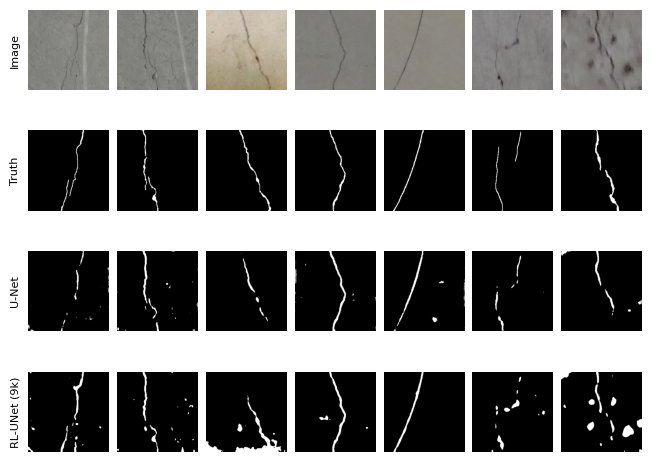

: 

In [ ]:
limit_min = 100
limit_max = 120
limit = 7

# Testing Dataset
testing_dir = "./CrackDatabase/omnicrack30k/images/test/"
target_dir = "./CrackDatabase/omnicrack30k/annotations/test/"
# model_dir_1 = "./model_state/UNET_OmniCrack30k_072515_155812.pth"
model_dir_1 = "./model_state/FINAL_UNET_crackseg9k_200_4.pth"
model_dir_2 = "./model_state/RLUNET_CRACK500_072517_175456.pth"
# model_dir_3 = "./model_state/FINAL_RLUNET_OmniCrack30k_400_16_v2.pth"
# model_dir_3 = "./model_state/RLUNET_crackseg9k_072528_002146.pth"
model_dir_3 = "./model_state/RLUNET_CC_072528_150829.pth"

model_1 = UNet(n_channels=3, n_classes=1).to('cuda')
model_2 = RLUNet().to('cuda')
model_3 = RLUNet().to('cuda')

model_1.load_state_dict(torch.load(model_dir_1)['state_dict'], strict=False)
model_2.load_state_dict(torch.load(model_dir_2), strict=False)
model_3.load_state_dict(torch.load(model_dir_3), strict=False)
image_test = OmniCrack30kDataset(testing_dir, 
                                 target_dir, 
                                 limit=limit_max+1)
image_test = DataLoader(dataset=image_test,
                        batch_size=1
                        )

image_l = [im for im in image_test]
print(image_l[2][0].shape, end="\n")

idx = 1
plt.figure(figsize=(32, 8))
fig = plt.figure(constrained_layout=True)
subfigs = fig.subfigures(nrows=4, ncols=1)
# fig.suptitle('OmniCrack30k')

subfigs[0].supylabel('Image', fontsize=8)
axs = subfigs[0].subplots(nrows=1, ncols=limit)
for img, ax in zip(image_l[limit_min:limit_max], axs):
    idx = idx + 1
    ax.imshow(img[0].squeeze(0).permute(1, 2, 0))
    ax.axis('off')

subfigs[1].supylabel('Truth', fontsize=8)
axs = subfigs[1].subplots(nrows=1, ncols=limit)
for img, ax in zip(image_l[limit_min:limit_max], axs):
    idx = idx + 1
    ax.imshow(img[1].squeeze(0).permute(1, 2, 0), cmap='gray')
    ax.axis('off')

subfigs[2].supylabel('U-Net', fontsize=8)
axs = subfigs[2].subplots(nrows=1, ncols=limit)
for im, ax in zip(image_l[limit_min:limit_max], axs):
    idx = idx + 1
    image = im[0].float().to('cuda')
    mask = im[1].float().to('cuda')
    res = model_1(image)
    dice = dice_coeff(res, mask)
    res = res.squeeze(0).cpu().detach().numpy()
    res_show = res.transpose(1, 2, 0)
    res_show[res_show < 0] = 0
    res_show[res_show > 0] = 1

    ax.imshow(res_show, cmap='gray')
    # ax.set_title(f'DICE: {dice:.3f}', fontsize=5)
    ax.axis('off')

subfigs[3].supylabel('RL-UNet (9k)', fontsize=8)
axs = subfigs[3].subplots(nrows=1, ncols=limit)
for im, ax in zip(image_l[limit_min:limit_max], axs):
    idx = idx + 1
    image = im[0].float().to('cuda')
    mask = im[1].float().to('cuda')
    res = model_2(image)
    dice = dice_coeff(res, mask)
    res = res.squeeze(0).cpu().detach().numpy()
    res_show = res.transpose(1, 2, 0)
    res_show[res_show < 0] = 0
    res_show[res_show > 0] = 1

    ax.imshow(res_show, cmap='gray')
    # ax.set_title(f'DICE: {dice:.3f}', fontsize=5)
    ax.axis('off')

plt.show()

## SEGMENTATION TO IMAGE

In [ ]:
begin = 70
end = 73
img_dir = "./CrackDatabase/crackseg9k/Test/Image/"
target_dir = "./CrackDatabase/crackseg9k/Test/Mask/"
net_dir = "./model_state/UNET_OmniCrack30k_072515_155812.pth"
net = UNet(n_channels=3, n_classes=1).to('cuda')
net.load_state_dict(torch.load(net_dir), strict=False)

image_in = CrackSeg9kDataset(img_dir, target_dir, limit=100)
image_in = DataLoader(dataset=image_in, batch_size=1)
image_l = [im for im in image_in]
cnt = 1

for im in image_l[begin:end]:
    # For file data id
    checkpoint_datetime = datetime.datetime.now()
    day = checkpoint_datetime.strftime("%d")
    month = checkpoint_datetime.strftime("%m")
    year = checkpoint_datetime.strftime("%y")
    hour = checkpoint_datetime.strftime("%H")
    minute = checkpoint_datetime.strftime("%M")
    second = checkpoint_datetime.strftime("%S")
    file_name_out = f"segmentation_result/{day}{month}{year}{hour}{cnt}.bmp"

    image = im[0].float().to('cuda')
    res = net(image)
    res[res < 0] = 0
    res[res > 0] = 1
    print(res.shape)
    transform = transforms.ToPILImage()
    image_out = transform(res[0])
    print(image_out)
    image_out.save(file_name_out)
    cnt = cnt + 1

torch.Size([1, 1, 400, 400])
<PIL.Image.Image image mode=L size=400x400 at 0x1E4C2E05570>
torch.Size([1, 1, 400, 400])
<PIL.Image.Image image mode=L size=400x400 at 0x1E4C2EFDC30>
torch.Size([1, 1, 400, 400])
<PIL.Image.Image image mode=L size=400x400 at 0x1E4C2EFF220>
